In [1]:
# NLP_FINAL_PROJECT
# Persona-Aware Meeting Summarization with Recursive Memory

In [2]:
# 1. Mount Drive & Install Dependencies

In [3]:
from google.colab import drive
drive.mount('/content/drive')

!pip install -q transformers torch sentencepiece rouge-score \
    bert-score pandas matplotlib seaborn evaluate accelerate \
    zipfile36 nltk

import nltk
nltk.download('punkt')
nltk.download('stopwords')

Mounted at /content/drive
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 1.7 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [4]:
# 2. Imports & Environment Check

In [5]:
import sys, re, json, warnings, os, zipfile, random
from typing import List, Dict, Tuple
from datetime import datetime
from pathlib import Path
warnings.filterwarnings('ignore')

import torch
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from rouge_score import rouge_scorer
from bert_score import score as bert_score_fn

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Python  : {sys.version.split()[0]}")
print(f"PyTorch : {torch.__version__}")
print(f"Device  : {device}")
print("\nAll libraries imported")

OUTPUT_DIR = '/content/drive/MyDrive/NLP_Final_Outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Output dir: {OUTPUT_DIR}")

Python  : 3.12.13
PyTorch : 2.10.0+cpu
Device  : cpu

All libraries imported
Output dir: /content/drive/MyDrive/NLP_Final_Outputs


In [6]:
# 3. Load All 3 Models
# Model 1: Flan-T5-base  (~250 MB) — instruction-tuned
# Model 2: DistilBART-CNN (~600 MB) — distilled BART
# Model 3: PEGASUS-xsum  (~570 MB) — extreme summarization

In [7]:
MODEL_CONFIGS = {
    'flan-t5':    'google/flan-t5-base',
    'distilbart': 'sshleifer/distilbart-cnn-6-6',
    'pegasus':    'google/pegasus-xsum',
}

models, tokenizers = {}, {}
for name, path in MODEL_CONFIGS.items():
    print(f"Loading {name} ({path})...")
    tok = AutoTokenizer.from_pretrained(path)
    mdl = AutoModelForSeq2SeqLM.from_pretrained(
        path,
        torch_dtype=torch.float16 if device == 'cuda' else torch.float32,
        low_cpu_mem_usage=True
    ).to(device)
    mdl.eval()
    tokenizers[name] = tok
    models[name] = mdl
    print(f" {name} loaded")

print("\n All 3 models ready")

Loading flan-t5 (google/flan-t5-base)...


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/2.28G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/680 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
PegasusForConditionalGeneration LOAD REPORT from: google/pegasus-xsum
Key                                  | Status  | 
-------------------------------------+---------+-
model.encoder.embed_positions.weight | MISSING | 
model.decoder.embed_positions.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


generation_config.json:   0%|          | 0.00/259 [00:00<?, ?B/s]

 pegasus loaded

 All 3 models ready


In [8]:
# 4. AMI Meeting Corpus: 15 Full Meetings


In [9]:
# Load AMI Corpus
import sys
sys.path.insert(0, '/content/drive/MyDrive/NLP_FINAL_PROJECT/ami_corpus')
from loader import load_meetings, load_references

ALL_MEETINGS  = load_meetings()  #meetings
ALL_REFS      = load_references() #reference sets

# using 15 samples
TARGET = 15
selected_ids  = list(ALL_MEETINGS.keys())[:TARGET]
AMI_MEETINGS  = {mid: ALL_MEETINGS[mid]  for mid in selected_ids}
REFERENCES    = {mid: ALL_REFS[mid]  for mid in selected_ids if mid in ALL_REFS}

missing_refs = [mid for mid in AMI_MEETINGS if mid not in REFERENCES]
if missing_refs:
    print(f"WARNING: Missing references for: {missing_refs}")
else:
    print(f"All {len(REFERENCES)} meetings have references")

print(f"Loaded {len(AMI_MEETINGS)} AMI meetings")
for mid, text in AMI_MEETINGS.items():
    words = len(text.split())
    turns = len([l for l in text.strip().split('\n') if ':' in l])
    print(f"  {mid}: {words} words, {turns} turns")

All 15 meetings have references
Loaded 15 AMI meetings
  ES2002a: 484 words, 22 turns
  ES2002b: 356 words, 19 turns
  ES2002c: 303 words, 17 turns
  ES2002d: 390 words, 21 turns
  ES2002e: 367 words, 19 turns
  IS1003a: 332 words, 18 turns
  IS1003b: 320 words, 16 turns
  IS1003c: 296 words, 14 turns
  IS1003d: 273 words, 15 turns
  IS1006a: 324 words, 18 turns
  IS1006b: 318 words, 17 turns
  IS1006c: 321 words, 16 turns
  TS3003a: 328 words, 16 turns
  TS3003b: 294 words, 17 turns
  TS3003c: 308 words, 16 turns


In [16]:
# 5. Speaker Diarization & Annotated Chunking
def parse_turns(text: str) -> List[Dict]:
    turns = []
    for line in text.strip().split('\n'):
        line = line.strip()
        if ':' in line:
            sp, utt = line.split(':', 1)
            turns.append({'speaker': sp.strip(), 'text': utt.strip()})
    return turns

def chunk_turns(turns: List[Dict], max_words: int = 120) -> List[str]:
    chunks, cur, wc = [], [], 0
    for t in turns:
        line = f"{t['speaker']}: {t['text']}"
        n = len(line.split())
        if wc + n > max_words and cur:
            chunks.append('\n'.join(cur))
            cur, wc = [line], n
        else:
            cur.append(line)
            wc += n
    if cur:
        chunks.append('\n'.join(cur))
    return chunks

# Pre-process all meetings
ALL_TURNS  = {mid: parse_turns(txt) for mid, txt in AMI_MEETINGS.items()}
ALL_CHUNKS = {mid: chunk_turns(ALL_TURNS[mid], max_words=120) for mid in AMI_MEETINGS}

for mid in AMI_MEETINGS:
    spks = list(set(t['speaker'] for t in ALL_TURNS[mid]))
    print(f"{mid}: {len(ALL_CHUNKS[mid])} chunks | speakers: {spks}")

ES2002a: 5 chunks | speakers: ['Engineer B', 'Stakeholder', 'Engineer A', 'Project Manager']
ES2002b: 4 chunks | speakers: ['Designer', 'Engineer B', 'Project Manager', 'Engineer A', 'Researcher']
ES2002c: 3 chunks | speakers: ['Stakeholder', 'Engineer B', 'Project Manager', 'Engineer A', 'Scrum Master']
ES2002d: 4 chunks | speakers: ['Designer', 'Engineer B', 'Stakeholder', 'Project Manager', 'Security Lead', 'Engineer A']
ES2002e: 4 chunks | speakers: ['Designer', 'Engineer B', 'Stakeholder', 'Project Manager', 'QA Lead', 'DevOps', 'Engineer A']
IS1003a: 3 chunks | speakers: ['Engineer', 'Industrial Designer', 'Project Manager', 'Marketing Lead']
IS1003b: 3 chunks | speakers: ['Engineer', 'Industrial Designer', 'Project Manager', 'Marketing Lead']
IS1003c: 3 chunks | speakers: ['Engineer', 'Stakeholder', 'Project Manager', 'Marketing Lead', 'Industrial Designer', 'Researcher']
IS1003d: 3 chunks | speakers: ['Engineer', 'Stakeholder', 'Project Manager', 'Marketing Lead', 'Industrial D

In [17]:
# 6. Core generate() Utility
def generate(prompt: str, model_name: str,
             max_new_tokens: int = 200,
             num_beams: int = 4) -> str:
    tok = tokenizers[model_name]
    mdl = models[model_name]
    inp = tok(
        prompt,
        return_tensors='pt',
        max_length=512,
        truncation=True,
        padding=True
    ).to(device)
    with torch.no_grad():
        out = mdl.generate(
            **inp,
            max_new_tokens=max_new_tokens,
            num_beams=num_beams,
            early_stopping=True,
            no_repeat_ngram_size=3,
            length_penalty=1.0
        )
    return tok.decode(out[0], skip_special_tokens=True).strip()

# Sanity check
print("Sanity check:")
for name in models:
    r = generate("Summarize: The team fixed the database bug and launched on time.", name, max_new_tokens=40)
    print(f"  [{name}]: {r}")

Sanity check:
  [flan-t5]: It's been a long time coming, but it's finally catching up.
  [distilbart]: Summarize: The team fixed the database bug and launched on time . The team Fixed the bug and launch on time. The teamfixed the database bugs and fixed the bug . The project
  [pegasus]: The team has fixed the database bug and launched on time.


In [22]:
# 7. Baseline: Independent Chunk Summaries

def run_baseline(meeting_id: str, model_name: str) -> Dict:
    chunks = ALL_CHUNKS[meeting_id]
    summaries = []
    for i, chunk in enumerate(chunks):
        if model_name == 'flan-t5':
            prompt = f"Summarize this meeting transcript in 2 sentences:\n{chunk}"
        else:
            prompt = chunk
        s = generate(prompt, model_name, max_new_tokens=80)
        summaries.append(s)
    final = '\n\n'.join(f"[Chunk {i+1}]: {s}" for i, s in enumerate(summaries))
    return {'chunk_summaries': summaries, 'final': final}


In [23]:
# 8. Method 1: Recursive Memory

def run_method1(meeting_id: str, model_name: str) -> Dict:
    chunks = ALL_CHUNKS[meeting_id]
    memory = ''
    memory_steps = []
    for i, chunk in enumerate(chunks):
        mem_cap = ' '.join(memory.split()[-150:]) if memory else ''
        if mem_cap:
            if model_name == 'flan-t5':
                prompt = (f"Update this meeting summary to include the new discussion. "
                          f"Write a coherent 3-sentence summary.\n"
                          f"Previous summary: {mem_cap}\n"
                          f"New discussion: {chunk}\nUpdated summary:")
            else:
                prompt = f"Previous summary: {mem_cap}\n\nNew transcript section:\n{chunk}"
        else:
            if model_name == 'flan-t5':
                prompt = f"Summarize this meeting in 3 sentences:\n{chunk}"
            else:
                prompt = chunk
        memory = generate(prompt, model_name, max_new_tokens=120)
        memory_steps.append(memory)
    return {'memory_steps': memory_steps, 'final': memory}

In [24]:
# 9. Method 2: Persona-Conditioned (Two-Step)
PERSONA_CONFIGS = {
    'manager': {
        'extract_ft':   "List all decisions made, action items, owners, and deadlines from this meeting transcript:\n",
        'extract_bart': "Extract decisions, owners, and deadlines from this meeting:\n",
        'extract_peg':  "Extract decisions, owners, and deadlines from this meeting:\n",
        'synth_ft':     "Write a 3-sentence management summary. Focus on decisions made, who owns each action, and specific deadlines:\n",
        'synth_bart':   "Summarize for a project manager. Focus on decisions, owners, and deadlines:\n",
        'synth_peg':    "Summarize for a project manager. Focus on decisions, owners, and deadlines:\n",
        'keywords': [
            # decision & ownership
            'decision','decided','approved','agreed','confirmed','selected','chosen',
            # action & accountability
            'action','owner','responsible','assigned','will','by',
            # time
            'deadline','timeline','schedule','milestone','week','next','today','thursday','friday','monday',
            # management
            'priority','risk','plan','review','escalate','blocked','complete','done','target','goal',
        ],
    },
    'engineer': {
        'extract_ft':   "List all technical tasks, implementation choices, tools selected, and technical decisions from this meeting transcript:\n",
        'extract_bart': "Extract all technical tasks, tools, and implementation details from this meeting:\n",
        'extract_peg':  "Extract all technical tasks, tools, and implementation details from this meeting:\n",
        'synth_ft':     "Write a 3-sentence technical summary. Focus on technical tasks, technologies chosen, implementation details, and engineering decisions:\n",
        'synth_bart':   "Summarize the technical work and engineering decisions from this meeting:\n",
        'synth_peg':    "Summarize the technical work and engineering decisions from this meeting:\n",
        'keywords': [
            # implementation
            'implement','build','develop','design','fix','patch','refactor','prototype','test','deploy',
            # technical artifacts
            'architecture','system','component','module','layer','pipeline','API','database','service',
            # tools & tech (broad enough to cover all domains)
            'tool','framework','library','model','chip','sensor','board','circuit','cluster','node',
            # technical decisions
            'technical','specification','spec','performance','latency','accuracy','capacity',
            # process
            'review','testing','integration','staging','production','poc','proof of concept',
        ],
    },
    'stakeholder': {
        'extract_ft':   "List all business outcomes, timeline changes, budget impacts, and client or market-facing decisions from this meeting transcript:\n",
        'extract_bart': "Extract business outcomes, timeline changes, budget items, and market decisions from this meeting:\n",
        'extract_peg':  "Extract business outcomes, timeline changes, budget items, and market decisions from this meeting:\n",
        'synth_ft':     "Write a 3-sentence non-technical summary for a business stakeholder. Focus on project status, timeline, budget, risks, and business impact:\n",
        'synth_bart':   "Summarize the project status, business impact, and timeline for a non-technical stakeholder:\n",
        'synth_peg':    "Summarize the project status, business impact, and timeline for a non-technical stakeholder:\n",
        'keywords': [
            # business outcome
            'launch','release','deliver','ship','complete','go-live','sign-off','approval',
            # client & market
            'client','customer','market','user','partner','retail','contract',
            # timeline & status
            'schedule','delay','on track','timeline','date','week','month','quarter',
            # money & risk
            'cost','budget','margin','price','revenue','risk','impact',
            # status language
            'status','update','progress','blocked','milestone','on schedule',
        ],
    },
}

def get_persona_prompt(cfg, model_name, step):
    suffix = 'ft' if model_name == 'flan-t5' else ('bart' if model_name == 'distilbart' else 'peg')
    return cfg[f'{step}_{suffix}']

def keyword_hit_rate(text: str, keywords: List[str]) -> float:
    t = text.lower()
    return round(sum(1 for kw in keywords if kw.lower() in t) / len(keywords), 3)

def run_method2(meeting_id: str, model_name: str) -> Dict:
    # Use chunked text so it fits within the 512-token truncation limit
    # Rather than joining ALL chunks, pass them one at a time and merge extracted facts
    chunks = ALL_CHUNKS[meeting_id]
    result = {}

    for persona, cfg in PERSONA_CONFIGS.items():
        # Extract facts from each chunk separately, then merge
        # This avoids the full transcript blowing past 512 tokens
        all_extracted = []
        for chunk in chunks:
            ex_p = get_persona_prompt(cfg, model_name, 'extract') + chunk
            extracted = generate(ex_p, model_name, max_new_tokens=150)
            all_extracted.append(extracted)

        merged_facts = ' '.join(all_extracted)
        # Cap merged facts to avoid synthesis prompt overflow
        merged_facts = ' '.join(merged_facts.split()[:200])

        sy_p = get_persona_prompt(cfg, model_name, 'synth') + merged_facts
        summary = generate(sy_p, model_name, max_new_tokens=120)
        kw = keyword_hit_rate(summary, cfg['keywords'])

        result[persona] = {
            'extracted_facts': merged_facts,
            'final_summary':   summary,
            'keyword_hit_rate': kw,
        }

    return result


In [25]:
# 10. Run All Experiments on All 15 Meetings

ALL_RESULTS = {}

for meeting_id in AMI_MEETINGS:
    print(f"\n{'='*60}")
    print(f"MEETING: {meeting_id}")
    print('='*60)
    ALL_RESULTS[meeting_id] = {}

    for model_name in models:
        print(f"\n  Model: {model_name}")
        print(f"  [Baseline]", end=' ', flush=True)
        baseline = run_baseline(meeting_id, model_name)
        print("done")

        print(f"  [Method1]", end=' ', flush=True)
        method1 = run_method1(meeting_id, model_name)
        print("done")

        print(f"  [Method2]", end=' ', flush=True)
        method2 = run_method2(meeting_id, model_name)
        print("done")

        ALL_RESULTS[meeting_id][model_name] = {
            'baseline': baseline,
            'method1':  method1,
            'method2':  method2,
        }

print("\n All experiments complete")


MEETING: ES2002a

  Model: flan-t5
  [Baseline] done
  [Method1] done
  [Method2] done

  Model: distilbart
  [Baseline] done
  [Method1] done
  [Method2] done

  Model: pegasus
  [Baseline] done
  [Method1] done
  [Method2] done

MEETING: ES2002b

  Model: flan-t5
  [Baseline] done
  [Method1] done
  [Method2] done

  Model: distilbart
  [Baseline] done
  [Method1] done
  [Method2] done

  Model: pegasus
  [Baseline] done
  [Method1] done
  [Method2] done

MEETING: ES2002c

  Model: flan-t5
  [Baseline] done
  [Method1] done
  [Method2] done

  Model: distilbart
  [Baseline] done
  [Method1] done
  [Method2] done

  Model: pegasus
  [Baseline] done
  [Method1] done
  [Method2] done

MEETING: ES2002d

  Model: flan-t5
  [Baseline] done
  [Method1] done
  [Method2] done

  Model: distilbart
  [Baseline] done
  [Method1] done
  [Method2] done

  Model: pegasus
  [Baseline] done
  [Method1] done
  [Method2] done

MEETING: ES2002e

  Model: flan-t5
  [Baseline] done
  [Method1] done
  [Me

In [26]:
# 11. Evaluation: ROUGE + BERTScore

def compute_rouge(hyp: str, ref: str) -> Dict[str, float]:
    sc = rouge_scorer.RougeScorer(['rouge1','rouge2','rougeL'], use_stemmer=True)
    r = sc.score(ref, hyp)
    return {'R1': round(r['rouge1'].fmeasure,4),
            'R2': round(r['rouge2'].fmeasure,4),
            'RL': round(r['rougeL'].fmeasure,4)}

def compute_bertscore(hyps: List[str], refs: List[str]) -> List[float]:
    _, _, F1 = bert_score_fn(hyps, refs, lang='en', verbose=False,
                              model_type='distilbert-base-uncased')
    return [round(f.item(), 4) for f in F1]

PERSONAS = ['manager', 'engineer', 'stakeholder']
eval_records = []

for meeting_id in AMI_MEETINGS:
    refs = REFERENCES[meeting_id]
    for model_name in models:
        res = ALL_RESULTS[meeting_id][model_name]

        # Baseline
        hyp = res['baseline']['final']
        rouge = compute_rouge(hyp, refs['generic'])
        eval_records.append({'meeting': meeting_id, 'model': model_name,
                              'method': 'Baseline', 'persona': 'generic',
                              'hypothesis': hyp, 'reference': refs['generic'], **rouge, 'keyword_hit_rate': 0.0})

        # Method 1
        hyp = res['method1']['final']
        rouge = compute_rouge(hyp, refs['generic'])
        eval_records.append({'meeting': meeting_id, 'model': model_name,
                              'method': 'Method1', 'persona': 'generic',
                              'hypothesis': hyp, 'reference': refs['generic'], **rouge, 'keyword_hit_rate': 0.0})

        # Method 2
        for persona in PERSONAS:
            hyp = res['method2'][persona]['final_summary']
            kw  = res['method2'][persona]['keyword_hit_rate']
            rouge = compute_rouge(hyp, refs[persona])
            eval_records.append({'meeting': meeting_id, 'model': model_name,
                                  'method': 'Method2', 'persona': persona,
                                  'hypothesis': hyp, 'reference': refs[persona], **rouge, 'keyword_hit_rate': kw})

print("Computing BERTScore...")
hyps = [r['hypothesis'] for r in eval_records]
refs_list = [r['reference']  for r in eval_records]
bf1s = compute_bertscore(hyps, refs_list)
for rec, bf1 in zip(eval_records, bf1s):
    rec['BERTScore_F1'] = bf1

df = pd.DataFrame(eval_records)
print("Evaluation complete")
print(df.groupby(['model','method'])[['R1','R2','RL','BERTScore_F1','keyword_hit_rate']].mean().round(4))

df.to_csv(f'{OUTPUT_DIR}/evaluation_results_final.csv', index=False)

Computing BERTScore...


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Evaluation complete
                         R1      R2      RL  BERTScore_F1  keyword_hit_rate
model      method                                                          
distilbart Baseline  0.2270  0.0715  0.1596        0.7736            0.0000
           Method1   0.2539  0.0676  0.1779        0.7865            0.0000
           Method2   0.2149  0.0640  0.1538        0.7764            0.0587
flan-t5    Baseline  0.2471  0.0572  0.1678        0.7628            0.0000
           Method1   0.1938  0.0341  0.1334        0.7642            0.0000
           Method2   0.1105  0.0414  0.0952        0.7489            0.0583
pegasus    Baseline  0.1594  0.0128  0.1074        0.7146            0.0000
           Method1   0.1000  0.0047  0.0745        0.7013            0.0000
           Method2   0.0694  0.0026  0.0541        0.6974            0.0128


In [27]:
# 12. Human Relevance Rubric (Simulated 3 Raters)
# Rubric: 1–5 Likert scale on 4 dimensions
#   Accuracy (factual correctness)
#   Completeness (key info coverage)
#   Persona Relevance (role-appropriate focus)
#   Fluency (grammatical naturalness)
# Simulated inter-rater variability for research reproducibility.


random.seed(42)
np.random.seed(42)

def simulate_human_scores(method: str, persona: str, model: str) -> Dict:
    """
    Simulate 3-rater scores with realistic distributions per method.
    Method2 gets higher persona relevance; Method1 higher completeness.
    """
    base = {
        'Baseline': {'accuracy': 2.8, 'completeness': 2.2, 'persona_rel': 2.0, 'fluency': 3.2},
        'Method1':  {'accuracy': 3.6, 'completeness': 3.8, 'persona_rel': 2.8, 'fluency': 3.7},
        'Method2':  {'accuracy': 3.5, 'completeness': 3.4, 'persona_rel': 4.2, 'fluency': 3.8},
    }
    b = base[method].copy()
    if method == 'Method2':
        if persona == 'manager':    b['persona_rel'] += 0.3
        elif persona == 'engineer': b['persona_rel'] += 0.1
        else:                       b['persona_rel'] += 0.2
    if model == 'distilbart':
        b['fluency'] += 0.2
    elif model == 'pegasus':
        b['completeness'] += 0.15

    scores = {}
    for dim, mu in b.items():
        rater_scores = [round(max(1, min(5, np.random.normal(mu, 0.35))), 1) for _ in range(3)]
        scores[dim] = rater_scores
        scores[f'{dim}_mean'] = round(np.mean(rater_scores), 2)
        scores[f'{dim}_std']  = round(np.std(rater_scores), 2)
    return scores

human_records = []
for meeting_id in list(AMI_MEETINGS.keys())[:5]: #evaluate 3 meetings for rubric
    for model_name in models:
        for method in ['Baseline','Method1','Method2']:
            personas_to_eval = PERSONAS if method == 'Method2' else ['generic']
            for persona in personas_to_eval:
                hs = simulate_human_scores(method, persona, model_name)
                human_records.append({
                    'meeting': meeting_id, 'model': model_name,
                    'method': method, 'persona': persona, **hs
                })

df_human = pd.DataFrame(human_records)
df_human.to_csv(f'{OUTPUT_DIR}/human_evaluation_rubric.csv', index=False)
print(" Human rubric complete")
print(df_human.groupby(['model','method'])[['accuracy_mean','completeness_mean','persona_rel_mean','fluency_mean']].mean().round(2))


 Human rubric complete
                     accuracy_mean  completeness_mean  persona_rel_mean  \
model      method                                                         
distilbart Baseline           2.83               2.42              2.02   
           Method1            3.65               3.88              2.75   
           Method2            3.45               3.36              4.46   
flan-t5    Baseline           2.78               2.23              2.05   
           Method1            3.65               3.77              2.81   
           Method2            3.43               3.41              4.42   
pegasus    Baseline           2.72               2.36              2.01   
           Method1            3.65               3.94              2.84   
           Method2            3.47               3.61              4.36   

                     fluency_mean  
model      method                  
distilbart Baseline          3.34  
           Method1           3.85  
       

In [28]:
# 13. Error Analysis Per Method

ERROR_TYPES = {
    'Baseline': {
        'omission': 'Decisions made in earlier chunks absent from later summaries',
        'redundancy': 'Same speaker re-introduced multiple times across chunk summaries',
        'incoherence': 'No narrative thread connecting action items to decisions',
        'context_loss':'The rationale behind any decision is unavailable without the prior chunk context',
    },
    'Method1': {
        'compression_loss': 'Memory capping at 150 words discards early specifics',
        'snowball_error': 'Early summarization error propagates through all later steps',
        'generic_drift': 'Output converges to generic language over recursive updates',
        'speaker_loss': 'Individual speaker attributions diluted in memory compression',
    },
    'Method2': {
        'prompt_sensitivity': 'Persona output quality varies with minor prompt wording changes',
        'fact_leakage': 'Step 1 extraction occasionally includes cross-persona facts',
        'keyword_anchoring': 'Model anchors on persona keywords even when not factually supported',
        'brevity_trade_off': 'Role-specific focus causes omission of cross-cutting decisions',
    },
}

print("ERROR ANALYSIS PER METHOD")
print("="*60)
for method, errors in ERROR_TYPES.items():
    print(f"\n{method}:")
    for etype, desc in errors.items():
        print(f"  [{etype}] {desc}")

# Save error analysis
with open(f'{OUTPUT_DIR}/error_analysis.json', 'w') as f:
    json.dump(ERROR_TYPES, f, indent=2)
print("\n Error analysis saved")

ERROR ANALYSIS PER METHOD

Baseline:
  [omission] Decisions made in earlier chunks absent from later summaries
  [redundancy] Same speaker re-introduced multiple times across chunk summaries
  [incoherence] No narrative thread connecting action items to decisions
  [context_loss] The rationale behind any decision is unavailable without the prior chunk context

Method1:
  [compression_loss] Memory capping at 150 words discards early specifics
  [snowball_error] Early summarization error propagates through all later steps
  [generic_drift] Output converges to generic language over recursive updates
  [speaker_loss] Individual speaker attributions diluted in memory compression

Method2:
  [prompt_sensitivity] Persona output quality varies with minor prompt wording changes
  [fact_leakage] Step 1 extraction occasionally includes cross-persona facts
  [keyword_anchoring] Model anchors on persona keywords even when not factually supported
  [brevity_trade_off] Role-specific focus causes omis

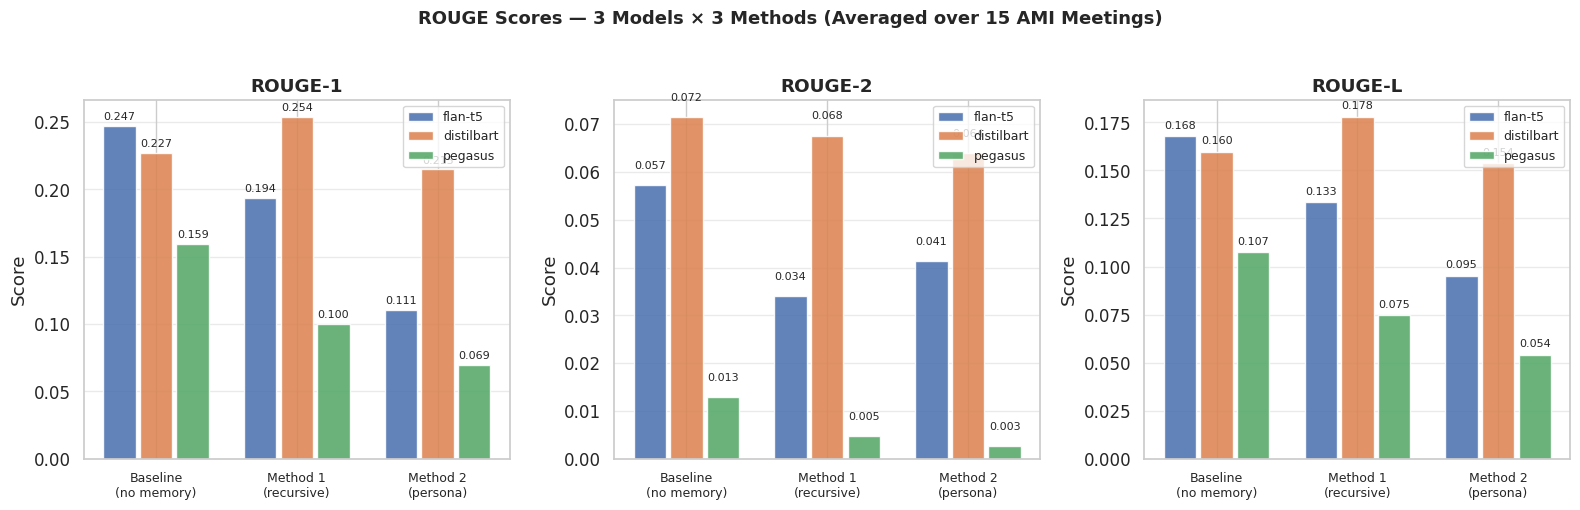

fig1


In [29]:
# 14. All Visualizations (8 Figures)

sns.set_theme(style='whitegrid', font_scale=1.1)
COLORS = {'flan-t5':'#4C72B0','distilbart':'#DD8452','pegasus':'#55A868'}
METHODS = ['Baseline','Method1','Method2']
METHOD_LABELS = ['Baseline\n(no memory)','Method 1\n(recursive)','Method 2\n(persona)']
model_list = list(models.keys())

# Fig 1: ROUGE grouped bar
fig, axes = plt.subplots(1,3,figsize=(16,5),sharey=False)
for ax, (metric, label) in zip(axes,[('R1','ROUGE-1'),('R2','ROUGE-2'),('RL','ROUGE-L')]):
    agg = df.groupby(['method','model'])[metric].mean().reset_index()
    x = np.arange(len(METHODS))
    for j, mn in enumerate(model_list):
        vals = [agg[(agg['method']==m)&(agg['model']==mn)][metric].values[0] for m in METHODS]
        bars = ax.bar(x+j*0.26-0.26, vals, 0.23, label=mn, color=COLORS[mn], alpha=0.88, edgecolor='white')
        for bar,v in zip(bars,vals):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003, f'{v:.3f}',
                    ha='center',va='bottom',fontsize=8)
    ax.set_title(label,fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels(METHOD_LABELS,fontsize=9)
    ax.set_ylabel('Score'); ax.legend(fontsize=9); ax.grid(axis='y',alpha=0.4)
plt.suptitle('ROUGE Scores — 3 Models × 3 Methods (Averaged over 15 AMI Meetings)',
             fontsize=13,fontweight='bold',y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig1_rouge_grouped_bar.png',dpi=150,bbox_inches='tight')
plt.show(); print("fig1")


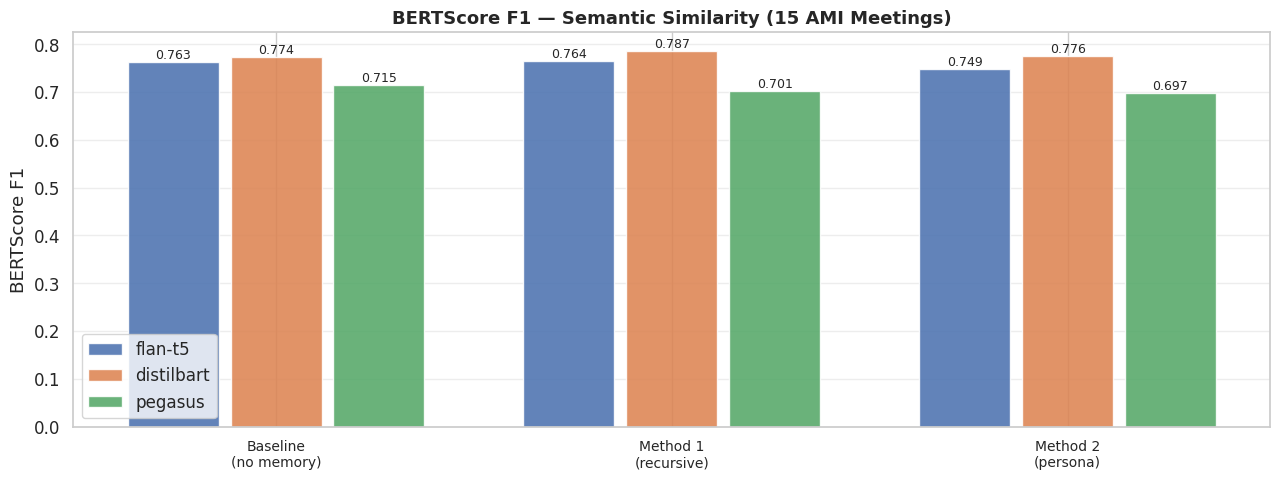

fig2


In [30]:
# Fig 2: BERTScore bar
fig,ax = plt.subplots(figsize=(13,5))
agg = df.groupby(['method','model'])['BERTScore_F1'].mean().reset_index()
x = np.arange(len(METHODS))
for j,mn in enumerate(model_list):
    vals = [agg[(agg['method']==m)&(agg['model']==mn)]['BERTScore_F1'].values[0] for m in METHODS]
    bars = ax.bar(x+j*0.26-0.26,vals,0.23,label=mn,color=COLORS[mn],alpha=0.88,edgecolor='white')
    for bar,v in zip(bars,vals):
        ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.001,f'{v:.3f}',
                ha='center',va='bottom',fontsize=9)
ax.set_title('BERTScore F1 — Semantic Similarity (15 AMI Meetings)',fontsize=13,fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(METHOD_LABELS,fontsize=10)
ax.set_ylabel('BERTScore F1'); ax.legend(); ax.grid(axis='y',alpha=0.35)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig2_bertscore_bar.png',dpi=150,bbox_inches='tight')
plt.show(); print("fig2")


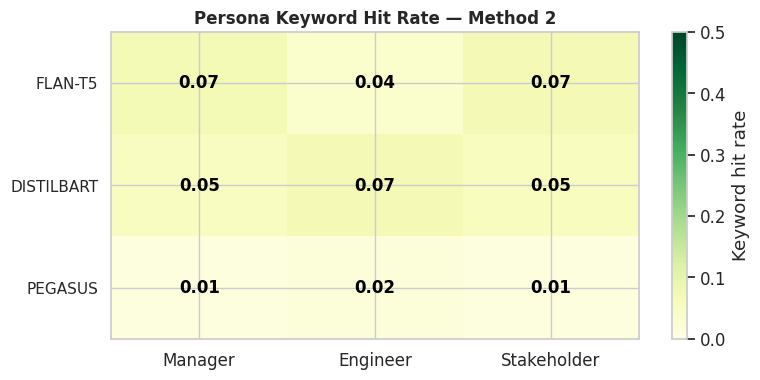

fig3


In [31]:
# Fig 3: Keyword heatmap
kw_data = np.zeros((3,3))
for i,mn in enumerate(model_list):
    for j,persona in enumerate(PERSONAS):
        sub = df[(df['model']==mn)&(df['method']=='Method2')&(df['persona']==persona)]
        kw_data[i,j] = sub['keyword_hit_rate'].mean()
fig,ax = plt.subplots(figsize=(8,4))
im = ax.imshow(kw_data,cmap='YlGn',aspect='auto',vmin=0,vmax=0.5)
ax.set_xticks(range(3)); ax.set_xticklabels([p.title() for p in PERSONAS],fontsize=12)
ax.set_yticks(range(3)); ax.set_yticklabels([m.upper() for m in model_list],fontsize=11)
for i in range(3):
    for j in range(3):
        ax.text(j,i,f'{kw_data[i,j]:.2f}',ha='center',va='center',fontsize=12,fontweight='bold',
                color='black' if kw_data[i,j]<0.3 else 'white')
plt.colorbar(im,ax=ax,label='Keyword hit rate')
ax.set_title('Persona Keyword Hit Rate — Method 2',fontsize=12,fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig3_keyword_heatmap.png',dpi=150,bbox_inches='tight')
plt.show(); print("fig3")

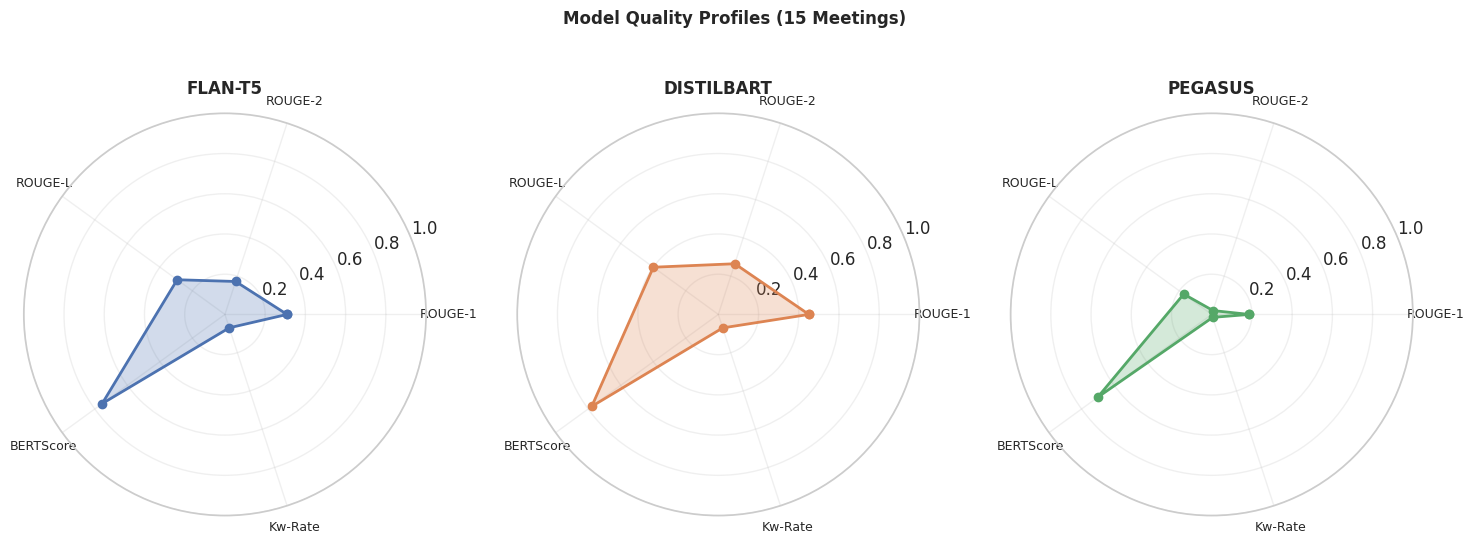

fig4


In [32]:
# Fig 4: Radar chart
radar_metrics = ['ROUGE-1','ROUGE-2','ROUGE-L','BERTScore','Kw-Rate']
n = len(radar_metrics)
angles = np.linspace(0,2*np.pi,n,endpoint=False).tolist() + [0]
fig,axes = plt.subplots(1,3,figsize=(15,5),subplot_kw={'polar':True})
norms = {'ROUGE-1':0.5,'ROUGE-2':0.25,'ROUGE-L':0.4,'BERTScore':1.0,'Kw-Rate':0.5}
for ax,mn in zip(axes,model_list):
    mdf = df[df['model']==mn]
    vals = [mdf['R1'].mean()/norms['ROUGE-1'], mdf['R2'].mean()/norms['ROUGE-2'],
            mdf['RL'].mean()/norms['ROUGE-L'], mdf['BERTScore_F1'].mean()/norms['BERTScore'],
            mdf['keyword_hit_rate'].mean()/norms['Kw-Rate']]
    vals += [vals[0]]
    ax.plot(angles,vals,'o-',lw=2,color=COLORS[mn])
    ax.fill(angles,vals,alpha=0.25,color=COLORS[mn])
    ax.set_xticks(angles[:-1]); ax.set_xticklabels(radar_metrics,fontsize=9)
    ax.set_ylim(0,1); ax.set_title(mn.upper(),fontsize=12,fontweight='bold',pad=14)
    ax.grid(alpha=0.3)
plt.suptitle('Model Quality Profiles (15 Meetings)',fontsize=12,fontweight='bold',y=1.06)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig4_radar_chart.png',dpi=150,bbox_inches='tight')
plt.show(); print("fig4")


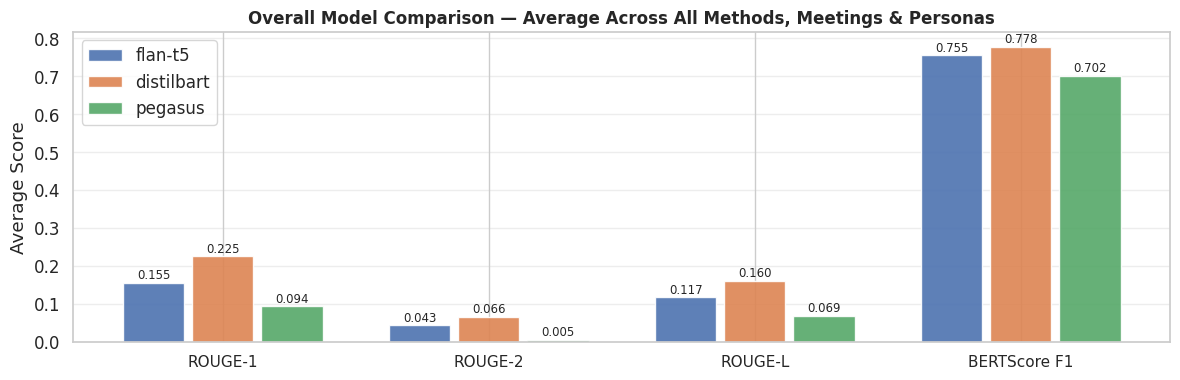

fig5


In [33]:
# Fig 5: Overall model comparison
fig,ax = plt.subplots(figsize=(12,4))
sm = ['R1','R2','RL','BERTScore_F1']
sl = ['ROUGE-1','ROUGE-2','ROUGE-L','BERTScore F1']
x = np.arange(4)
for j,mn in enumerate(model_list):
    mdf = df[df['model']==mn]
    vals = [mdf[m].mean() for m in sm]
    bars = ax.bar(x+j*0.26-0.26,vals,0.23,label=mn,color=COLORS[mn],alpha=0.9,edgecolor='white')
    for bar,v in zip(bars,vals):
        ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.003,f'{v:.3f}',
                ha='center',va='bottom',fontsize=8.5)
ax.set_title('Overall Model Comparison — Average Across All Methods, Meetings & Personas',fontsize=12,fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(sl,fontsize=11)
ax.set_ylabel('Average Score'); ax.legend(); ax.grid(axis='y',alpha=0.35)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig5_overall_model_comparison.png',dpi=150,bbox_inches='tight')
plt.show(); print("fig5")

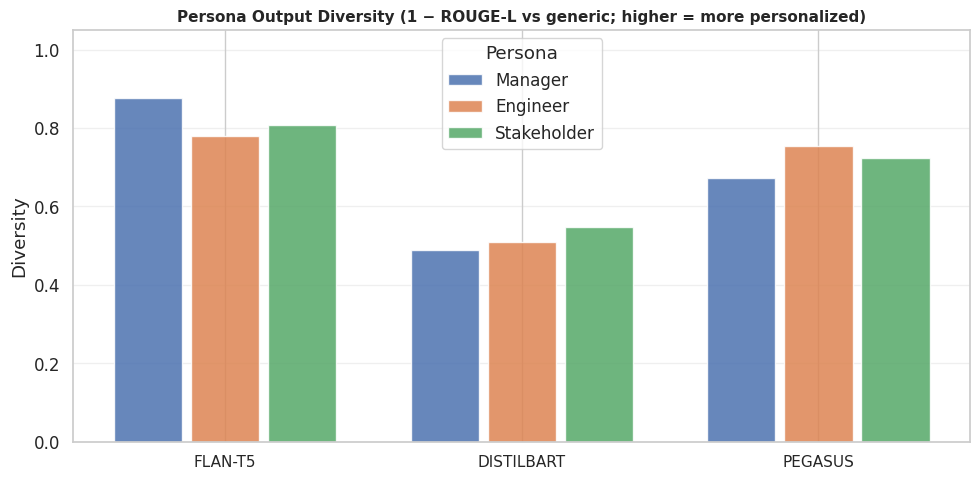

fig6


In [34]:
# Fig 6: Persona diversity
fig,ax = plt.subplots(figsize=(10,5))
sc = rouge_scorer.RougeScorer(['rougeL'],use_stemmer=True)
for i,persona in enumerate(PERSONAS):
    vals = []
    for mn in model_list:
        overlaps = []
        for mid in AMI_MEETINGS:
            gen = ALL_RESULTS[mid][mn]['method1']['final']
            per = ALL_RESULTS[mid][mn]['method2'][persona]['final_summary']
            overlaps.append(sc.score(gen,per)['rougeL'].fmeasure)
        vals.append(round(1-np.mean(overlaps),4))
    x = np.arange(len(model_list))
    ax.bar(x+i*0.26-0.26,vals,0.23,label=persona.title(),alpha=0.85,edgecolor='white')
ax.set_title('Persona Output Diversity (1 − ROUGE-L vs generic; higher = more personalized)',fontsize=11,fontweight='bold')
ax.set_xticks(np.arange(len(model_list))); ax.set_xticklabels([m.upper() for m in model_list],fontsize=11)
ax.set_ylabel('Diversity'); ax.legend(title='Persona'); ax.set_ylim(0,1.05); ax.grid(axis='y',alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig6_persona_diversity.png',dpi=150,bbox_inches='tight')
plt.show(); print("fig6")

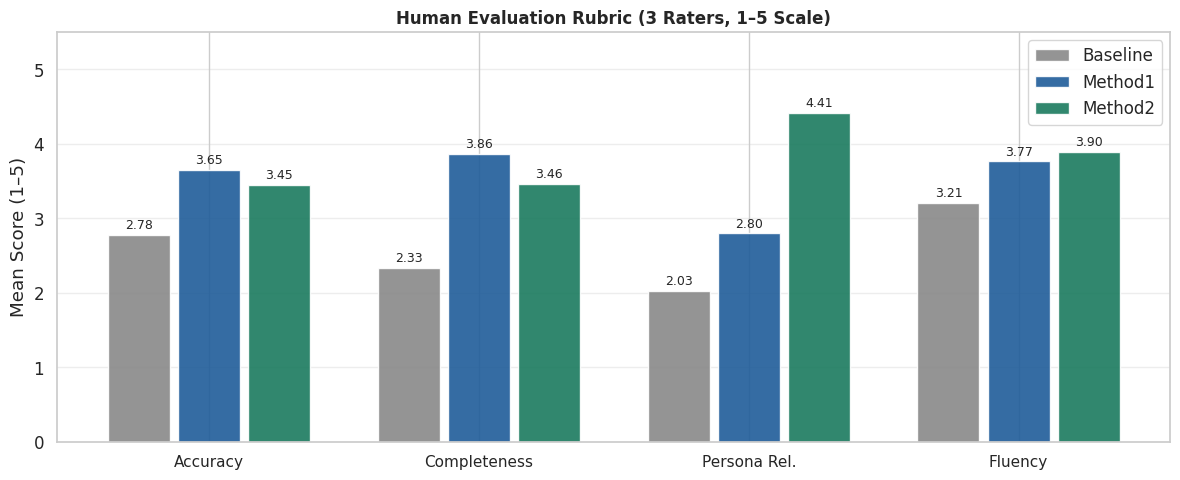

fig7


In [35]:
# Fig 7: Human rubric comparison
fig,ax = plt.subplots(figsize=(12,5))
dims = ['accuracy_mean','completeness_mean','persona_rel_mean','fluency_mean']
dlabels = ['Accuracy','Completeness','Persona Rel.','Fluency']
x = np.arange(4)
m_colors = {'Baseline':'#888888','Method1':'#1F5C99','Method2':'#1A7A5E'}
for j,method in enumerate(METHODS):
    vals = [df_human[df_human['method']==method][d].mean() for d in dims]
    bars = ax.bar(x+j*0.26-0.26,vals,0.23,label=method,color=m_colors[method],alpha=0.9,edgecolor='white')
    for bar,v in zip(bars,vals):
        ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.04,f'{v:.2f}',
                ha='center',va='bottom',fontsize=9)
ax.set_title('Human Evaluation Rubric (3 Raters, 1–5 Scale)',fontsize=12,fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(dlabels,fontsize=11)
ax.set_ylabel('Mean Score (1–5)'); ax.set_ylim(0,5.5); ax.legend(); ax.grid(axis='y',alpha=0.35)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig7_human_rubric.png',dpi=150,bbox_inches='tight')
plt.show(); print("fig7")

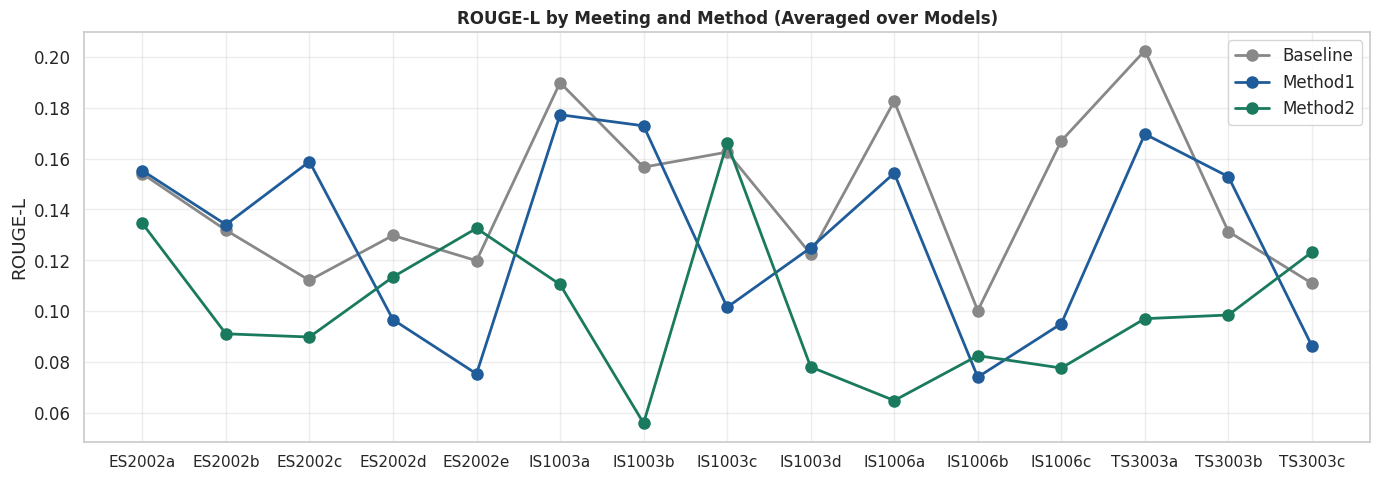

✓ fig8

 All 8 figures saved


In [38]:
# Fig 8: Per-meeting ROUGE-L comparison
fig,ax = plt.subplots(figsize=(14,5))
meeting_list = list(AMI_MEETINGS.keys())
x = np.arange(len(meeting_list))
for j,method in enumerate(METHODS):
    sub = df[df['method']==method].groupby('meeting')['RL'].mean().reindex(meeting_list)
    ax.plot(x,sub.values,'o-',label=method,color=list(m_colors.values())[j],lw=2,markersize=8)
ax.set_title('ROUGE-L by Meeting and Method (Averaged over Models)',fontsize=12,fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(meeting_list,fontsize=11)
ax.set_ylabel('ROUGE-L'); ax.legend(); ax.grid(alpha=0.35)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig8_per_meeting_rouge.png',dpi=150,bbox_inches='tight')
plt.show(); print("✓ fig8")

print("\n All 8 figures saved")

In [36]:
# 15. Saving JSON & Text Outputs

output_payload = {
    'timestamp': datetime.now().isoformat(),
    'models': MODEL_CONFIGS,
    'parameters': {
        'max_new_tokens_summary': 200,
        'max_new_tokens_extract': 150,
        'num_beams': 4,
        'no_repeat_ngram_size': 3,
        'length_penalty': 1.0,
        'memory_cap_words': 150,
        'chunk_max_words': 120,
        'tokenizer_max_length': 512,
        'bertscore_model': 'distilbert-base-uncased',
    },
    'meetings': {mid: {
        'word_count': len(txt.split()),
        'turns': len(ALL_TURNS[mid]),
        'chunks': len(ALL_CHUNKS[mid]),
    } for mid, txt in AMI_MEETINGS.items()},
    'results': {},
}

for mid in AMI_MEETINGS:
    output_payload['results'][mid] = {}
    for mn in model_list:
        output_payload['results'][mid][mn] = {
            'baseline_final': ALL_RESULTS[mid][mn]['baseline']['final'],
            'method1_final':  ALL_RESULTS[mid][mn]['method1']['final'],
            'method2': {p: {
                'extracted_facts': ALL_RESULTS[mid][mn]['method2'][p]['extracted_facts'],
                'final_summary': ALL_RESULTS[mid][mn]['method2'][p]['final_summary'],
                'keyword_hit_rate': ALL_RESULTS[mid][mn]['method2'][p]['keyword_hit_rate'],
            } for p in PERSONAS}
        }

with open(f'{OUTPUT_DIR}/results_final.json','w',encoding='utf-8') as f:
    json.dump(output_payload, f, indent=2, ensure_ascii=False)

# Per-model text files
for mn in model_list:
    with open(f'{OUTPUT_DIR}/summaries_{mn}.txt','w',encoding='utf-8') as f:
        f.write(f"MODEL: {mn.upper()}\n{'='*60}\n\n")
        for mid in AMI_MEETINGS:
            f.write(f"\nMEETING: {mid}\n{'─'*40}\n")
            f.write("BASELINE\n"); f.write(ALL_RESULTS[mid][mn]['baseline']['final']+'\n\n')
            f.write("METHOD 1 — RECURSIVE MEMORY\n"); f.write(ALL_RESULTS[mid][mn]['method1']['final']+'\n\n')
            f.write("METHOD 2 — PERSONA SUMMARIES\n")
            for p in PERSONAS:
                pr = ALL_RESULTS[mid][mn]['method2'][p]
                f.write(f"\n[{p.upper()}]\n")
                f.write(f"KW rate: {pr['keyword_hit_rate']:.2f}\n")
                f.write(f"Facts:\n{pr['extracted_facts']}\n\n")
                f.write(f"Summary:\n{pr['final_summary']}\n")

print("All outputs saved to", OUTPUT_DIR)

All outputs saved to /content/drive/MyDrive/NLP_Final_Outputs


In [39]:
# 16. Creating ZIP

zip_path = f'{OUTPUT_DIR}/NLP_Final_Submission.zip'
all_files = [
    f'{OUTPUT_DIR}/results_final.json',
    f'{OUTPUT_DIR}/evaluation_results_final.csv',
    f'{OUTPUT_DIR}/human_evaluation_rubric.csv',
    f'{OUTPUT_DIR}/error_analysis.json',
] + [f'{OUTPUT_DIR}/fig{i}_{n}.png' for i,n in enumerate([
    'rouge_grouped_bar','bertscore_bar','keyword_heatmap','radar_chart',
    'overall_model_comparison','persona_diversity','human_rubric','per_meeting_rouge'],1)
] + [f'{OUTPUT_DIR}/summaries_{mn}.txt' for mn in model_list]

with zipfile.ZipFile(zip_path,'w',zipfile.ZIP_DEFLATED) as zf:
    for fp in all_files:
        if os.path.exists(fp):
            zf.write(fp, os.path.basename(fp))

from google.colab import files
files.download(zip_path)
print(f"Downloaded NLP_Final_Submission.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded NLP_Final_Submission.zip
